In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/test-competition12545/sample_submission.csv
/kaggle/input/test-competition12545/time.txt


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
pd.options.display.max_columns=None

In [3]:
df = pd.read_csv('/kaggle/input/test-competition12545/sample_submission.csv')
df.head()

,Time,Seconds
0,30:06:45,NaN
1,25:07:51,NaN
2,49:38:39,NaN
3,97:42:39,NaN
4,68:44:13,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Time     500 non-null    object 
 1   Seconds  0 non-null      float64
dtypes: float64(1), object(1)
memory usage: 7.9+ KB


In [5]:
df.dtypes

Time        object
Seconds    float64
dtype: object

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Seconds,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.isnull().sum()/len('df')*100

Time           0.0
Seconds    25000.0
dtype: float64

In [8]:
df.shape

(500, 2)

<Axes: >

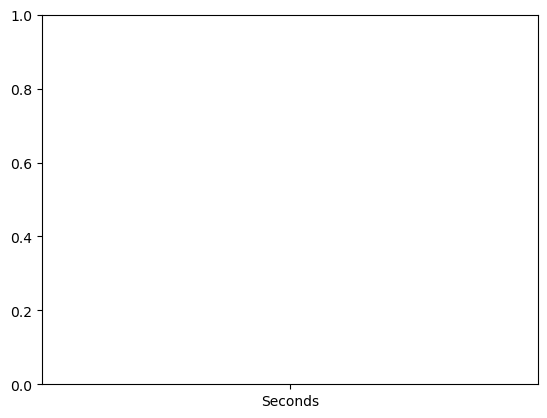

In [9]:
sns.boxplot(df)

<Axes: >

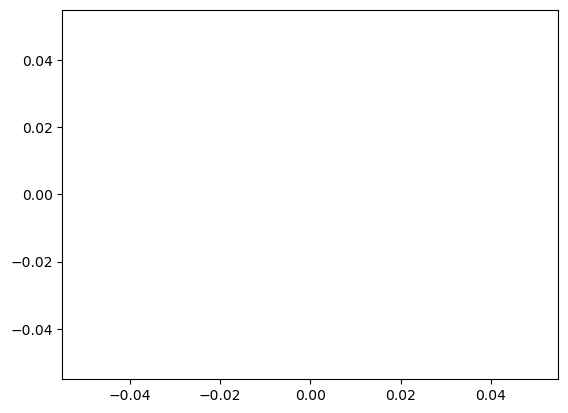

In [10]:
sns.scatterplot(df)

/tmp/ipykernel_32/4277794465.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(),annot=True)
/opt/conda/lib/python3.10/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/opt/conda/lib/python3.10/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


<Axes: >

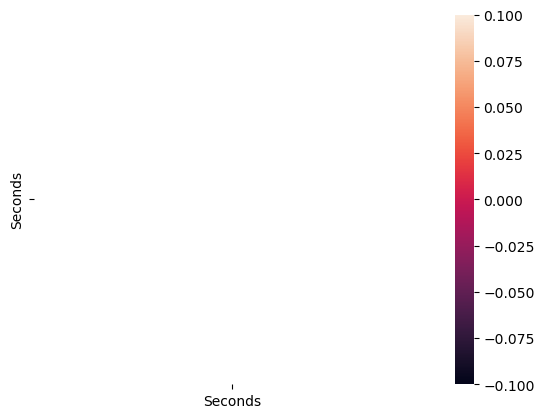

In [11]:
sns.heatmap(df.corr(),annot=True)

<Axes: ylabel='Density'>

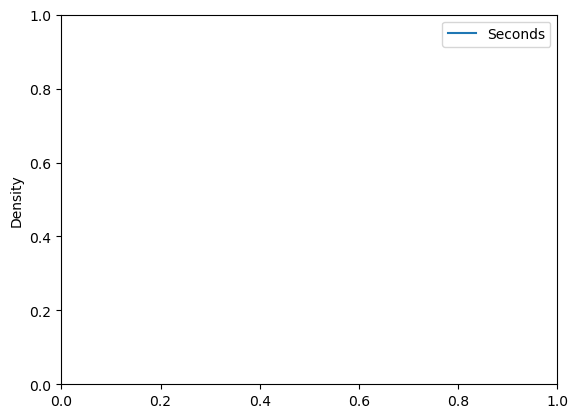

In [12]:
sns.kdeplot(df)

<Axes: >

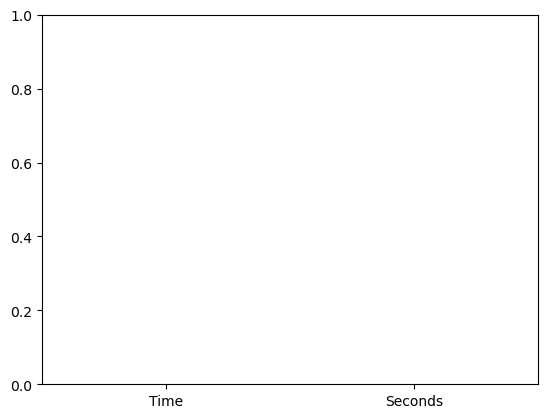

In [44]:
sns.violinplot(df)

/opt/conda/lib/python3.10/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
/opt/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1559: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a,


<Axes: >

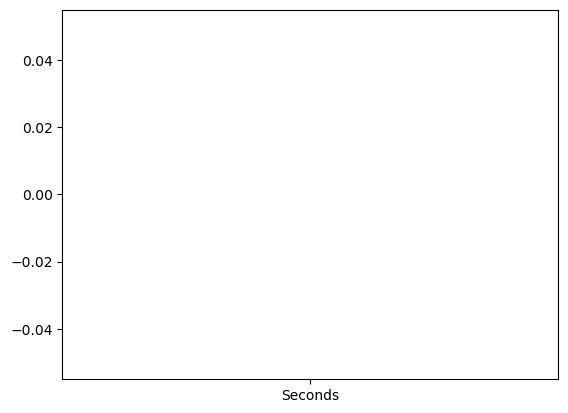

In [14]:
sns.barplot(df)

<Axes: ylabel='count'>

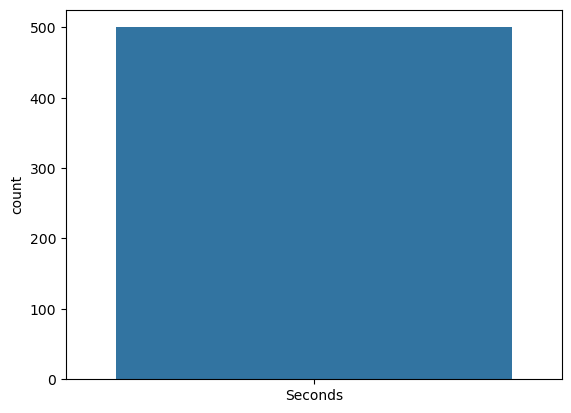

In [15]:
sns.countplot(df)


In [16]:
df.skew()

/tmp/ipykernel_32/1665899112.py:1: FutureWarning: The default value of numeric_only in DataFrame.skew is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.skew()


Seconds   NaN
dtype: float64

In [17]:
df.kurt()

/tmp/ipykernel_32/1257127604.py:1: FutureWarning: The default value of numeric_only in DataFrame.kurt is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.kurt()


Seconds   NaN
dtype: float64

In [19]:
df.head()

,Time,Seconds
0,30:06:45,NaN
1,25:07:51,NaN
2,49:38:39,NaN
3,97:42:39,NaN
4,68:44:13,NaN


In [20]:
cat_cols = df.select_dtypes(include='object')

In [21]:
for i in cat_cols:
    print(i)
    print(df[i].value_counts())
    print('_'*50)

Time
30:06:45    1
90:54:43    1
75:48:43    1
87:33:48    1
3:50:37     1
           ..
60:41:01    1
89:45:02    1
73:14:59    1
7:57:17     1
5:31:48     1
Name: Time, Length: 500, dtype: int64
__________________________________________________


In [22]:
num_cols = df.select_dtypes(include='number')

In [23]:
for i in num_cols:
    print(i)
    print(df[i].value_counts())
    print('_'*50)

Seconds
Series([], Name: Seconds, dtype: int64)
__________________________________________________


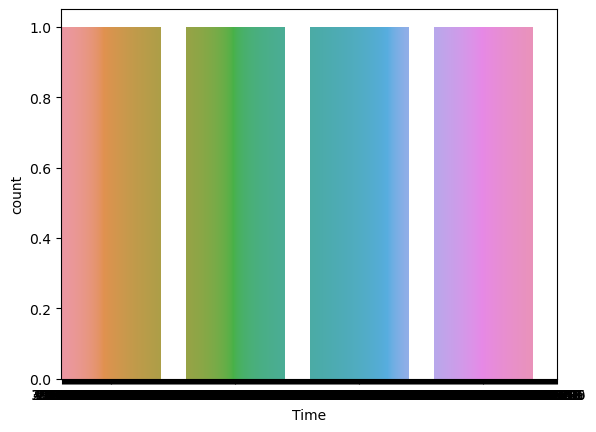

In [25]:
x=1
for i in cat_cols:
    sns.countplot(data=df,x=i)
    print('\n')
    plt.show()

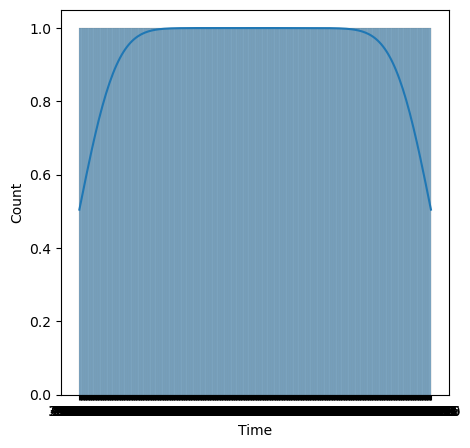

In [26]:
plt.figure(figsize=(5,5))
x=1
for i in cat_cols:
    sns.histplot(data=df,x=i,kde=True)
    print('\n')
    plt.show()

In [27]:
df['Time'].value_counts()

30:06:45    1
90:54:43    1
75:48:43    1
87:33:48    1
3:50:37     1
           ..
60:41:01    1
89:45:02    1
73:14:59    1
7:57:17     1
5:31:48     1
Name: Time, Length: 500, dtype: int64

In [28]:
df['Time'].unique()

array(['30:06:45', '25:07:51', '49:38:39', '97:42:39', '68:44:13',
       '1:40:48', '21:45:11', '88:52:02', '91:52:08', '91:28:42',
       '29:56:47', '88:36:51', '30:17:28', '46:52:33', '90:05:56',
       '54:04:43', '28:27:01', '13:11:51', '3:40:21', '75:48:39',
       '63:42:58', '44:05:13', '24:43:18', '40:53:28', '92:32:26',
       '78:19:51', '88:59:37', '7:46:29', '49:15:26', '2:08:10',
       '72:21:22', '55:56:00', '28:48:56', '15:45:42', '36:03:53',
       '10:35:49', '40:11:42', '33:07:53', '80:44:08', '36:59:31',
       '31:54:35', '35:33:16', '41:57:30', '94:28:20', '14:20:38',
       '5:24:28', '12:56:49', '99:55:40', '7:52:09', '95:15:36',
       '32:43:50', '71:53:11', '78:08:10', '79:13:18', '91:29:04',
       '66:49:00', '26:30:57', '0:15:33', '8:33:31', '49:35:13',
       '48:51:26', '74:45:43', '50:41:03', '58:10:51', '56:47:57',
       '50:07:35', '74:26:33', '56:35:10', '62:17:43', '16:32:49',
       '44:13:57', '19:59:10', '46:07:57', '76:37:20', '18:34:33',
   

In [29]:
df['Time']=df['Time'].map({'Good':2,'Standard':1,'Poor':0})

/opt/conda/lib/python3.10/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/opt/conda/lib/python3.10/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


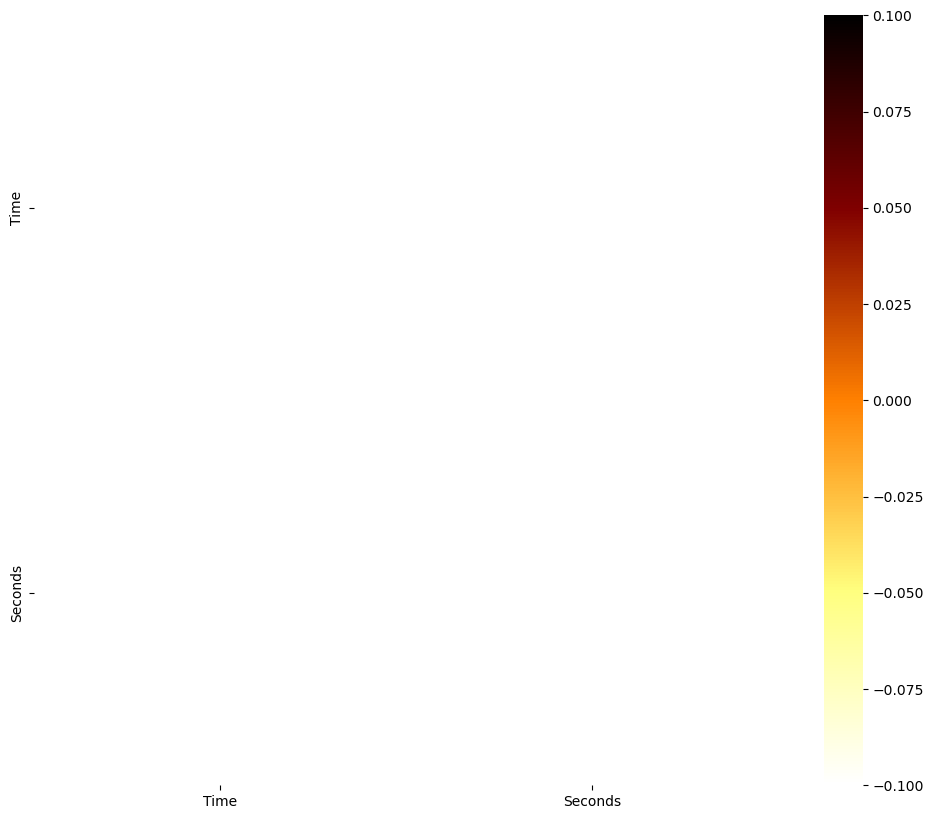

In [30]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),annot=True,cmap='afmhot_r')
plt.show()

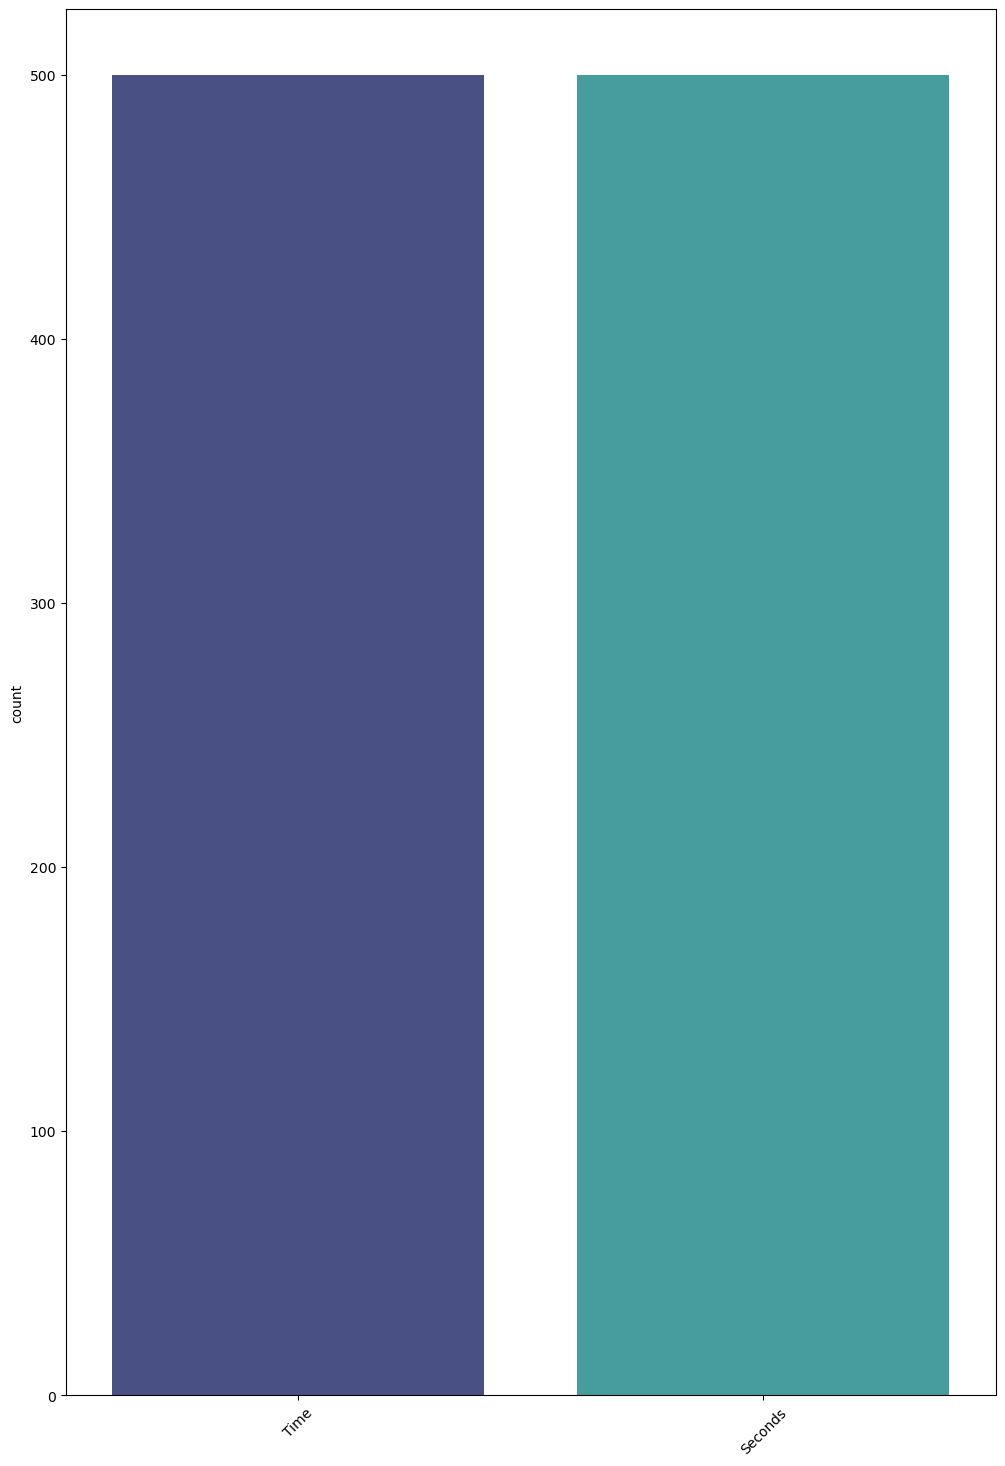

In [32]:
plt.figure(figsize=(12,18))
sns.countplot(df,palette='mako');
plt.xticks(rotation=45);

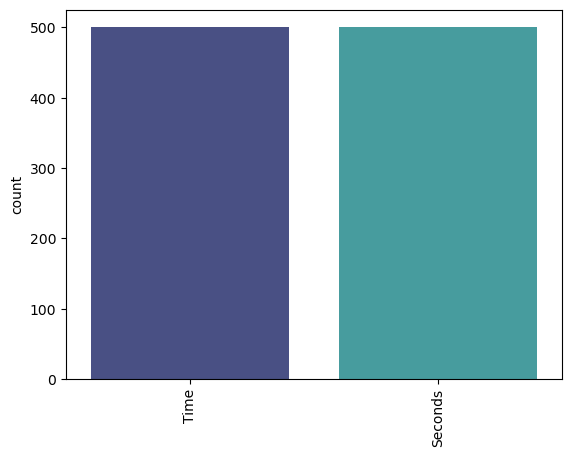

In [33]:
sns.countplot(df,palette='mako');
plt.xticks(rotation=90);

(array([0, 1]), [Text(0, 0, 'Time'), Text(1, 0, 'Seconds')])

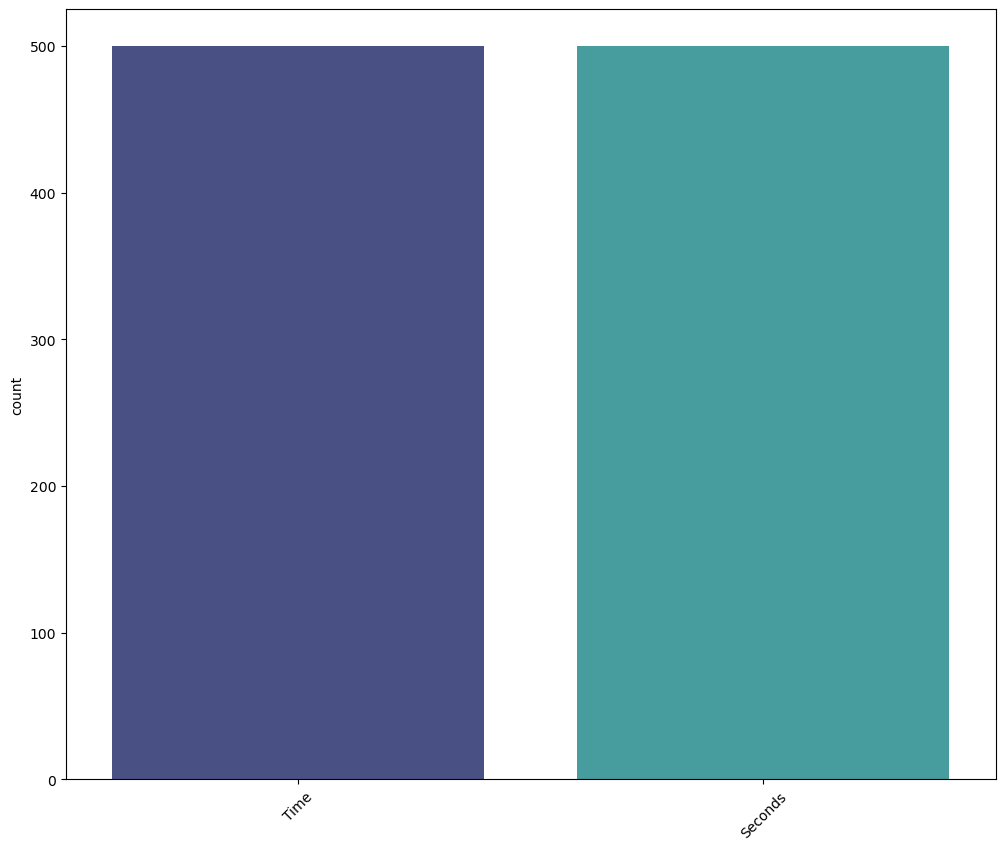

In [35]:
plt.figure(figsize=(12,10))
sns.countplot(df,palette='mako')
plt.xticks(rotation=45)

In [39]:
df.columns

Index(['Time', 'Seconds'], dtype='object')

In [43]:
df.sum()

Time       0.0
Seconds    0.0
dtype: float64

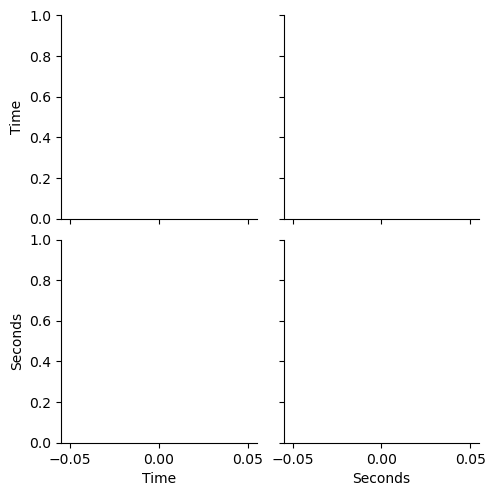

In [45]:
sns.pairplot(df)

In [50]:
from scipy.stats import zscore

In [52]:
df['Seconds']=zscore(df['Time'])


In [53]:
df[(df['Seconds']>3) | (df['Time']<-3)]

,Time,Seconds


In [54]:
df.head()

,Time,Seconds
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


In [55]:
x= df.drop('Time',axis=1)
y=df['Time']

In [56]:
from sklearn.model_selection import train_test_split

In [57]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)